In [ ]:
%pip install plotly -q
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118 -q


In [ ]:
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import time
import pandas as pd
import matplotlib.pyplot as plt
import random
import numpy as np

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

device = get_device()
print(f"Treinando no dispositivo: {device}")


Treinando no dispositivo: cuda


In [ ]:
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

# torch.use_deterministic_algorithms(True)


### 1) Carregando e Dividindo o Dataset (Treino, Val, Test)

In [ ]:
def get_full_fashionmnist(root="data"):
    transform = transforms.ToTensor()
    train_data_full = datasets.FashionMNIST(
        root=root,
        train=True,
        download=True,
        transform=transform
    )
    test_data = datasets.FashionMNIST(
        root=root,
        train=False,
        download=True,
        transform=transform
    )
    return train_data_full, test_data

def create_train_val_test_dataloaders(
    train_data_full,
    test_data,
    train_size=55000,
    val_size=5000,
    batch_size=32
):
    train_data, val_data = random_split(train_data_full, [train_size, val_size])

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_data, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

train_data_full, test_data = get_full_fashionmnist()
class_names = train_data_full.classes

BATCH_SIZE = 32
train_loader, val_loader, test_loader = create_train_val_test_dataloaders(
    train_data_full,
    test_data,
    train_size=55000,
    val_size=5000,
    batch_size=BATCH_SIZE
)

print(f"Tamanho do train_loader: {len(train_loader)} batches")
print(f"Tamanho do val_loader: {len(val_loader)} batches")
print(f"Tamanho do test_loader: {len(test_loader)} batches")

Tamanho do train_loader: 1719 batches
Tamanho do val_loader: 157 batches
Tamanho do test_loader: 313 batches


### 2) Função de Treino



In [ ]:
def train_model_with_val(
    model: nn.Module,
    train_dataloader: DataLoader,
    val_dataloader: DataLoader,
    loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    epochs: int = 5
):
    model = model.to(device)
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0
        epoch_train_acc = 0

        for X, y in train_dataloader:
            X, y = X.to(device), y.to(device)

            y_pred = model(X)

            loss = loss_fn(y_pred, y)
            epoch_train_loss += loss.item()

            y_pred_class = torch.argmax(y_pred, dim=1)
            epoch_train_acc += accuracy_fn(y, y_pred_class)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        epoch_train_loss /= len(train_dataloader)
        epoch_train_acc  /= len(train_dataloader)

        model.eval()
        epoch_val_loss = 0
        epoch_val_acc = 0
        with torch.inference_mode():
            for X_val, y_val in val_dataloader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                val_pred = model(X_val)
                loss_val = loss_fn(val_pred, y_val)
                epoch_val_loss += loss_val.item()
                epoch_val_acc  += accuracy_fn(y_val, val_pred.argmax(dim=1))

        epoch_val_loss /= len(val_dataloader)
        epoch_val_acc  /= len(val_dataloader)

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_accuracies.append(epoch_train_acc)
        val_accuracies.append(epoch_val_acc)

        print(f"[Epoch {epoch+1:02d}/{epochs}] "
              f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% "
              f"| Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accuracies,
        "val_accs": val_accuracies
    }

def evaluate_model(
    model: nn.Module,
    dataloader: DataLoader,
    loss_fn: nn.Module,
    device: torch.device
):
    model.eval()
    model.to(device)

    total_loss = 0
    total_acc = 0

    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            total_loss += loss.item()
            total_acc  += accuracy_fn(y, y_pred.argmax(dim=1))

    avg_loss = total_loss / len(dataloader)
    avg_acc  = total_acc / len(dataloader)
    return avg_loss, avg_acc

### 3) Definindo Diferentes Arquiteturas

In [ ]:
class MLPBaseline(nn.Module):
    def __init__(self, input_dim=28*28, hidden_units=128, output_dim=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_units),
            nn.ReLU(),
            nn.Linear(hidden_units, output_dim)
        )

    def forward(self, x):
        return self.net(x)


class MLBImproved(nn.Module):
    def __init__(self, input_shape: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_shape, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)


In [ ]:

class TinyVGG(nn.Module):
    def __init__(self, input_shape: int = 1, hidden_units: int = 16, output_shape: int = 10):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        return self.classifier(x)


class VGG16(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32,
                      kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=32, out_channels=64,
                      kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=64, out_channels=128,
                      kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            nn.Conv2d(in_channels=128, out_channels=128,
                      kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            nn.Conv2d(in_channels=128, out_channels=64,
                      kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


## 4) Treinando e Comparando todos os Modelos

In [ ]:
histories = {}

loss_fn = nn.CrossEntropyLoss()

models_dict = {
    "MLP": MLPBaseline(),
    "MLPImproved": MLBImproved(input_shape=28*28, output_shape=10),
    "TinyVGG": TinyVGG(input_shape=1, hidden_units=16, output_shape=10),
    "VGG16": VGG16(num_classes=10),
    "AlexNet": AlexNet(num_classes=10)
}

NUM_EPOCHS = 20
results = []

for model_name, model in models_dict.items():
    print(f"\n=== Treinando {model_name} ===")
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    num_params = count_parameters(model)

    start_time = time.time()
    history = train_model_with_val(
        model=model,
        train_dataloader=train_loader,
        val_dataloader=val_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=device,
        epochs=NUM_EPOCHS
    )
    end_time = time.time()
    train_time = end_time - start_time

    test_loss, test_acc = evaluate_model(model, test_loader, loss_fn, device)

    final_train_loss = history["train_losses"][-1]
    final_val_loss = history["val_losses"][-1]
    final_train_acc = history["train_accs"][-1]
    final_val_acc = history["val_accs"][-1]

    histories[model_name] = history
    results.append({
        "model": model_name,
        "num_params": num_params,
        "train_loss": final_train_loss,
        "train_acc": final_train_acc,
        "val_loss": final_val_loss,
        "val_acc": final_val_acc,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "train_time (s)": train_time
    })

df_results = pd.DataFrame(results)
df_results



=== Treinando MLP ===
[Epoch 01/5] Train Loss: 0.5214 | Train Acc: 81.89% | Val Loss: 0.4160 | Val Acc: 85.03%
[Epoch 02/5] Train Loss: 0.3884 | Train Acc: 86.11% | Val Loss: 0.3939 | Val Acc: 85.67%
[Epoch 03/5] Train Loss: 0.3460 | Train Acc: 87.38% | Val Loss: 0.4174 | Val Acc: 85.09%
[Epoch 04/5] Train Loss: 0.3246 | Train Acc: 88.20% | Val Loss: 0.3552 | Val Acc: 87.34%
[Epoch 05/5] Train Loss: 0.3015 | Train Acc: 88.85% | Val Loss: 0.3581 | Val Acc: 87.34%

=== Treinando MLPImproved ===
[Epoch 01/5] Train Loss: 0.5423 | Train Acc: 80.27% | Val Loss: 0.4233 | Val Acc: 85.01%
[Epoch 02/5] Train Loss: 0.4188 | Train Acc: 84.63% | Val Loss: 0.4001 | Val Acc: 85.33%
[Epoch 03/5] Train Loss: 0.3851 | Train Acc: 86.05% | Val Loss: 0.3698 | Val Acc: 86.56%
[Epoch 04/5] Train Loss: 0.3661 | Train Acc: 86.56% | Val Loss: 0.3593 | Val Acc: 87.26%
[Epoch 05/5] Train Loss: 0.3486 | Train Acc: 87.16% | Val Loss: 0.3729 | Val Acc: 87.14%

=== Treinando TinyVGG ===
[Epoch 01/5] Train Loss: 0.49

,model,num_params,train_loss,train_acc,val_loss,val_acc,test_loss,test_acc,train_time (s)
0,MLP,101770,0.301465,88.851319,0.358139,87.340764,0.369443,86.751198,49.768459
1,MLPImproved,535818,0.348579,87.161867,0.372914,87.141720,0.369359,86.940895,43.810876
2,TinyVGG,14970,0.243267,91.141289,0.269277,89.888535,0.276694,90.045927,51.416921
3,VGG16,7799626,0.271085,90.583188,0.280660,90.804140,0.282337,90.425319,125.760349
4,AlexNet,530122,0.252057,91.103718,0.268448,90.485669,0.278913,90.175719,59.174606


## 5) Exibir DataFrame de Resultados

In [ ]:
print("\nResultados finais:")

df_results


Resultados finais:


,model,num_params,train_loss,train_acc,val_loss,val_acc,test_loss,test_acc,train_time (s)
0,MLP,101770,0.301465,88.851319,0.358139,87.340764,0.369443,86.751198,49.768459
1,MLPImproved,535818,0.348579,87.161867,0.372914,87.141720,0.369359,86.940895,43.810876
2,TinyVGG,14970,0.243267,91.141289,0.269277,89.888535,0.276694,90.045927,51.416921
3,VGG16,7799626,0.271085,90.583188,0.280660,90.804140,0.282337,90.425319,125.760349
4,AlexNet,530122,0.252057,91.103718,0.268448,90.485669,0.278913,90.175719,59.174606


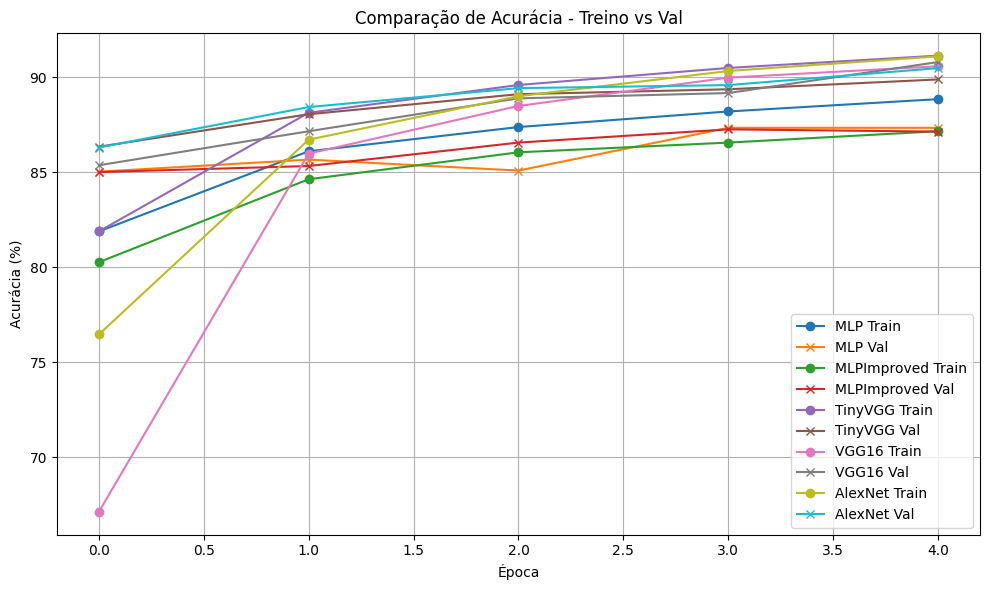

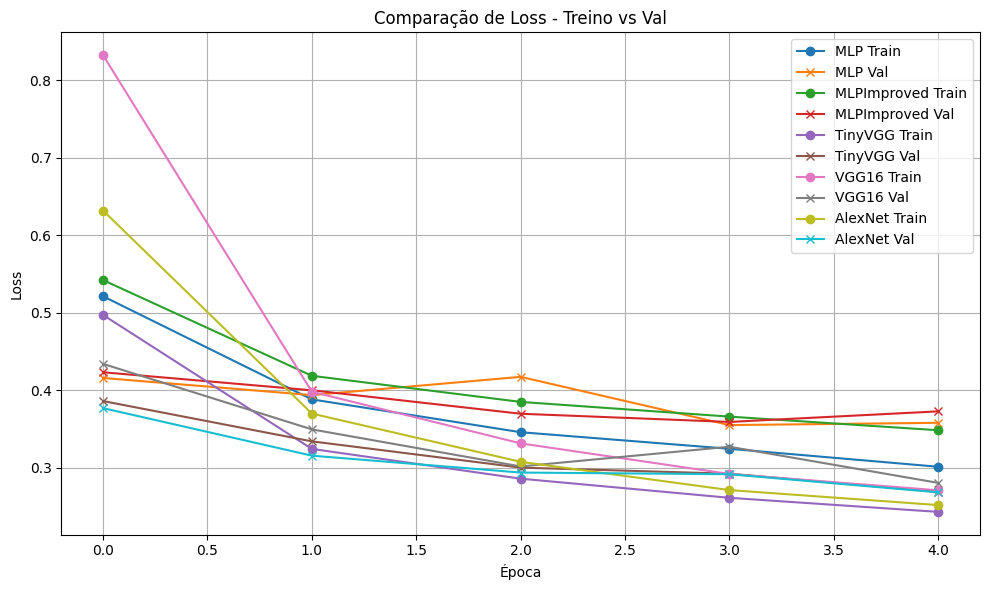

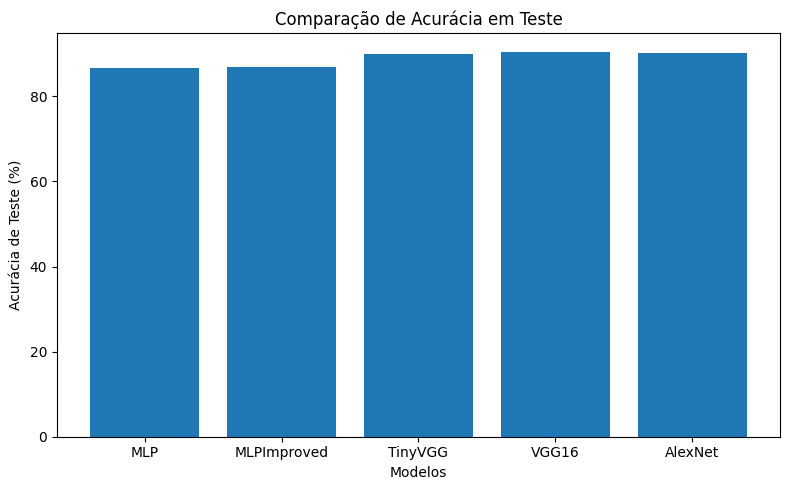

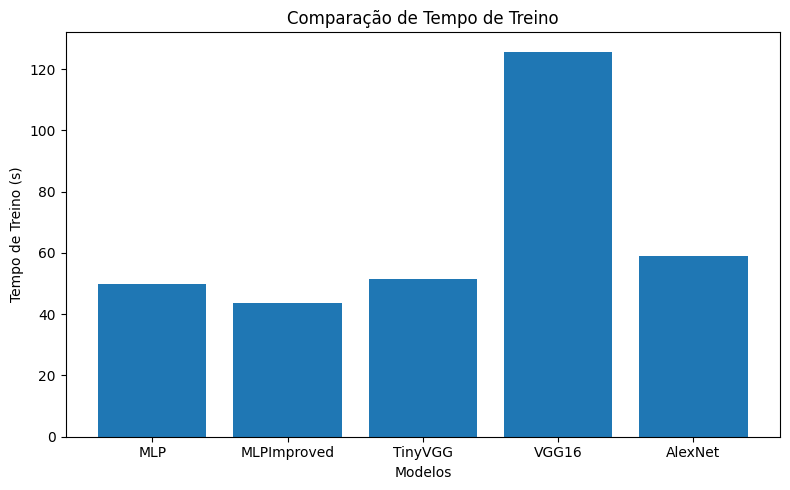

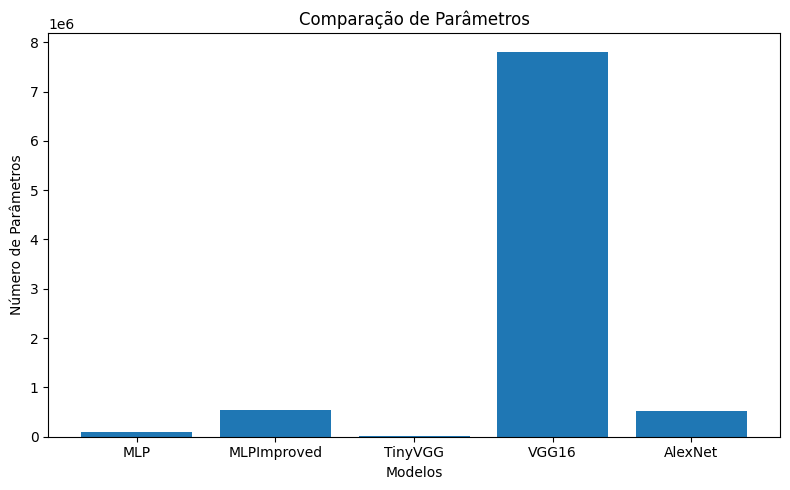

In [ ]:
plt.figure(figsize=(10, 6))
for model_name, hist in histories.items():
    plt.plot(hist["train_accs"], marker='o', label=f'{model_name} Train')
    plt.plot(hist["val_accs"], marker='x', label=f'{model_name} Val')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.title('Comparação de Acurácia - Treino vs Val')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
for model_name, hist in histories.items():
    plt.plot(hist["train_losses"], marker='o', label=f'{model_name} Train')
    plt.plot(hist["val_losses"], marker='x', label=f'{model_name} Val')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Comparação de Loss - Treino vs Val')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(df_results['model'], df_results['test_acc'])
plt.xlabel('Modelos')
plt.ylabel('Acurácia de Teste (%)')
plt.title('Comparação de Acurácia em Teste')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(df_results['model'], df_results['train_time (s)'])
plt.xlabel('Modelos')
plt.ylabel('Tempo de Treino (s)')
plt.title('Comparação de Tempo de Treino')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(df_results['model'], df_results['num_params'])
plt.xlabel('Modelos')
plt.ylabel('Número de Parâmetros')
plt.title('Comparação de Parâmetros')
plt.tight_layout()
plt.show()